# Light Trap Charge Investigation

Investigates charge hit positions relative to light trap (SiPM) locations
in the 2x2 detector using DTG data.

**Goals:**
1. Map charge activity relative to light trap positions
2. Compare near-trap vs far-from-trap populations (hit charge, light properties)
3. Analyze decay time dependence of near-trap events
4. Test the Pb-209 hypothesis (neutron activation of lead on light traps)

**Data:** Run 978 (DTG on), Runs 979/980 (decay) — reflow HDF5 files.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
from matplotlib.colors import LogNorm
from scipy.spatial import cKDTree
from scipy.optimize import curve_fit

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [2]:
import sys; sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "..", "utils"))
from dune_plot import apply_dune_style, dune_label
apply_dune_style()

In [28]:
from dtg_utils import (
    thd_correct, TRAP_NAME_MAP, sum_to_traps,
    get_trap_indices, reject_saturation, reject_late_peaks,
    compute_fprompt_fixed, compute_fprompt_dynamic,
    detect_pileup_find_peaks, detect_pileup_rising_tail,
    get_charge_hits_for_light_events, discover_files,
    SAT_THRESHOLD, PEAK_TICK_FIXED, PEAK_MAX_TICK,
    PILEUP_MIN_DISTANCE, PILEUP_MIN_REL_HEIGHT,
    PILEUP_LOOKBACK, PILEUP_TAIL_REL_HEIGHT,
    LCM_ENERGY_NORM, ENERGY_SCALE, N_MODULES,
    REFLOW_DIR, AR41_HALF_LIFE,
)

acl_idx, acl_tpc = get_trap_indices("acl")
lcm_idx, lcm_tpc = get_trap_indices("lcm")

# --- Configuration ---
DETECTOR = "lcm"
CHUNK_SIZE = 300
N_DTG_FILES = 5        # files from run 978 to process
N_DECAY_FILES = 5      # files from runs 979+980
NEAR_TRAP_CM = 5.0     # distance threshold for near-trap classification (cm)
COORD_LIMIT = 70.0      # reject hits with any coordinate > this (cm)

EN_BINS = np.arange(0, 3, 0.03)
FP_BINS = np.arange(0, 1, 0.01)

print(f"LCM traps (excl. TPC 6): {len(lcm_idx)}")

LCM traps (excl. TPC 6): 28


## Light Trap (SiPM) Positions

Read the 384 SiPM absolute positions from `geometry_info/sipm_abs_pos` in a reflow file.
Build a KD-tree for fast nearest-neighbor distance queries.

In [9]:
# Read SiPM positions from geometry_info in a sample reflow file
sample_file = discover_files(REFLOW_DIR, run=978)[0]

with h5py.File(sample_file, "r") as h:
    sipm_data = h["geometry_info/sipm_abs_pos/data"][:]

filled = sipm_data["filled"]
sipm_pos = sipm_data["data"][filled]  # (384, 3) -> [x, y, z] in cm

print(f"SiPM positions loaded: {sipm_pos.shape[0]}")
print(f"  x: [{sipm_pos[:,0].min():.2f}, {sipm_pos[:,0].max():.2f}] cm")
print(f"  y: [{sipm_pos[:,1].min():.2f}, {sipm_pos[:,1].max():.2f}] cm")
print(f"  z: [{sipm_pos[:,2].min():.2f}, {sipm_pos[:,2].max():.2f}] cm")

# Build KD-tree for 3D distance queries
sipm_tree = cKDTree(sipm_pos)

# Also build a y-z only tree (x = drift coordinate, sometimes unreliable)
sipm_tree_yz = cKDTree(sipm_pos[:, 1:3])

# Wall positions
unique_x = np.unique(np.round(sipm_pos[:, 0], 0))
unique_z = np.unique(np.round(sipm_pos[:, 2], 0))
print(f"\nSiPM wall x-positions (cm): {unique_x}")
print(f"SiPM wall z-positions (cm): {unique_z}")

SiPM positions loaded: 384
  x: [-63.94, 63.94] cm
  y: [-60.07, 60.07] cm
  z: [-64.99, 64.99] cm

SiPM wall x-positions (cm): [-64.  -3.   3.  64.]
SiPM wall z-positions (cm): [-65.  -2.   2.  65.]


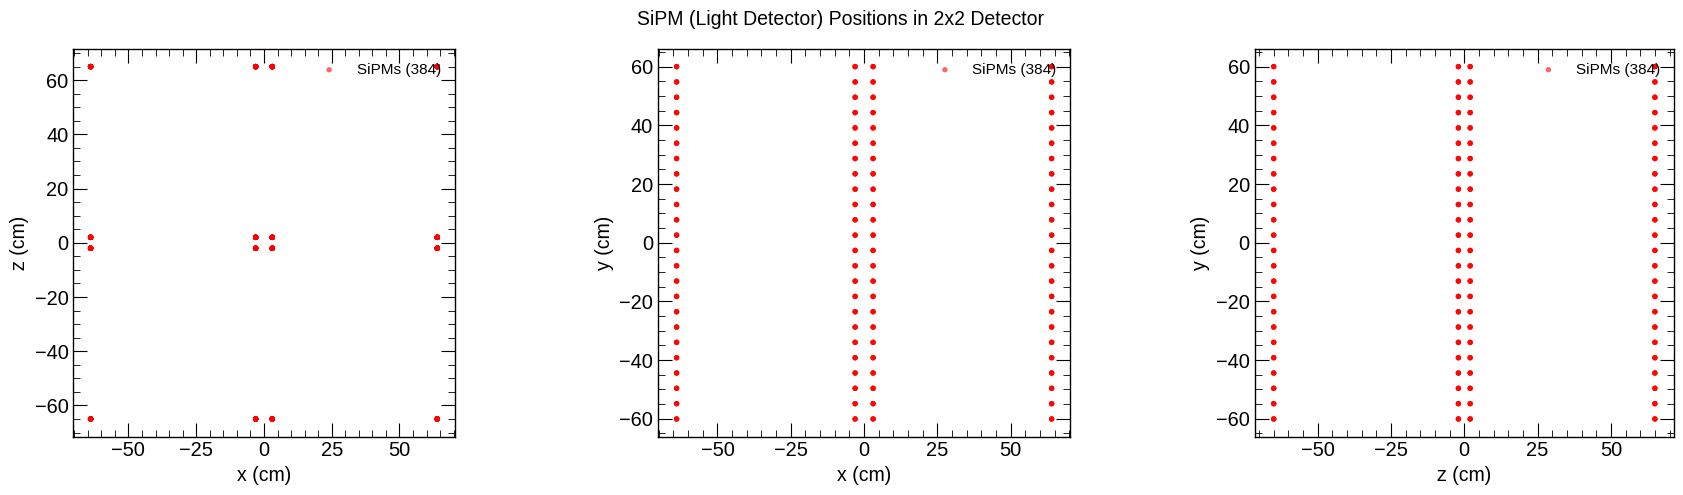

In [10]:
# Visualize SiPM positions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

proj_sipm = [
    (0, 2, "x (cm)", "z (cm)"),
    (0, 1, "x (cm)", "y (cm)"),
    (2, 1, "z (cm)", "y (cm)"),
]

for ax, (ix, iy, xl, yl) in zip(axes, proj_sipm):
    ax.scatter(sipm_pos[:, ix], sipm_pos[:, iy], s=15, c="red", alpha=0.6,
               edgecolors="none", label=f"SiPMs ({len(sipm_pos)})")
    ax.set_xlabel(xl, fontsize=14)
    ax.set_ylabel(yl, fontsize=14)
    ax.set_aspect("equal")
    ax.tick_params(direction="in")
    ax.legend(fontsize=11)

fig.suptitle("SiPM (Light Detector) Positions in 2x2 Detector", fontsize=14)
plt.tight_layout()
plt.show()

## DTG-On Data (Run 978) — Light + Charge

Process DTG-on reflow files with dynamic-peak fprompt for light,
charge hits via h5flow references. Same light processing as
`charge_selection_comparison.ipynb`.

In [11]:
files_978 = discover_files(REFLOW_DIR, run=978)
print(f"Run 978 (DTG on): {len(files_978)} files")

idx_978 = np.linspace(0, len(files_978) - 1, min(N_DTG_FILES, len(files_978)), dtype=int)
selected_978 = [files_978[i] for i in idx_978]
print(f"Selected: {len(selected_978)} files")


def process_dtg_on_file(path, chunk_size=CHUNK_SIZE):
    """Process one DTG-on reflow file: light (dynamic fprompt) + charge."""
    fp_lcm, en_lcm, np_lcm = [], [], []
    ev_indices = []

    with h5py.File(path, "r") as h:
        wvfm_ds = h["/light/wvfm/data"]["samples"]
        n_total = len(wvfm_ds)

        for start in range(0, n_total, chunk_size):
            stop = min(start + chunk_size, n_total)
            raw = wvfm_ds[start:stop]
            samples = thd_correct(raw.astype(np.float32)); del raw
            saturated = reject_saturation(samples, SAT_THRESHOLD)
            trap_wvfms = sum_to_traps(samples, TRAP_NAME_MAP).astype(np.float32); del samples

            late_peak = reject_late_peaks(trap_wvfms, PEAK_MAX_TICK)
            bad = saturated | late_peak
            good = ~bad

            fp, integral, _ = compute_fprompt_dynamic(trap_wvfms)
            npe = detect_pileup_find_peaks(
                trap_wvfms, PILEUP_MIN_DISTANCE, PILEUP_MIN_REL_HEIGHT
            )
            del trap_wvfms

            fp_lcm.append(fp[good][:, lcm_idx])
            en_lcm.append(integral[good][:, lcm_idx])
            np_lcm.append(npe[good][:, lcm_idx])
            ev_indices.append(np.arange(start, stop)[good])

    def cat(lst): return np.concatenate(lst, axis=0) if lst else np.array([]).reshape(0, 0)
    good_idx = np.concatenate(ev_indices) if ev_indices else np.array([], dtype=int)

    charge_data = get_charge_hits_for_light_events(path, good_idx)

    return {
        "fprompt_lcm": cat(fp_lcm), "energy_lcm": cat(en_lcm), "n_peaks_lcm": cat(np_lcm),
        "event_indices": good_idx,
        "charge_hits": charge_data["hits"],
        "charge_light_idx": charge_data["light_event_idx"],
    }

Run 978 (DTG on): 64 files
Selected: 5 files


In [12]:
results_978 = {}

for path in selected_978:
    fname = os.path.basename(path)
    print(f"Processing {fname} ...", end=" ", flush=True)
    try:
        results_978[path] = process_dtg_on_file(path)
        r = results_978[path]
        n_ev = r["fprompt_lcm"].shape[0] if r["fprompt_lcm"].ndim == 2 else 0
        n_hits = len(r["charge_hits"])
        print(f"done  \u2014 {n_ev:,} events, {n_hits:,} charge hits")
    except Exception as e:
        print(f"FAILED: {e}")

total_ev = sum(r["fprompt_lcm"].shape[0] for r in results_978.values()
               if r["fprompt_lcm"].ndim == 2)
total_hits = sum(len(r["charge_hits"]) for r in results_978.values())
print(f"\nTotal: {total_ev:,} events, {total_hits:,} charge hits across {len(results_978)} files")

Processing mpd_run_run2data_rctl_978_p0_v0p2.FLOW.hdf5 ... done  — 1,608 events, 55,702 charge hits
Processing mpd_run_run2data_rctl_978_p15_v0p2.FLOW.hdf5 ... done  — 3,631 events, 0 charge hits
Processing mpd_run_run2data_rctl_978_p31_v0p2.FLOW.hdf5 ... done  — 3,620 events, 728,198 charge hits
Processing mpd_run_run2data_rctl_978_p47_v0p2.FLOW.hdf5 ... done  — 3,685 events, 817,632 charge hits
Processing mpd_run_run2data_rctl_978_p65_v0p2.FLOW.hdf5 ... FAILED: 'Unable to synchronously open object (component not found)'

Total: 12,544 events, 1,601,532 charge hits across 4 files


## Charge Hit Spatial Distribution

All charge hits linked to light events, with SiPM positions overlaid.
Hits filtered to valid coordinates (finite, within detector bounds).

In [13]:
# Collect all charge hits from DTG-on files
hit_list, lidx_list, file_list = [], [], []
for path, r in results_978.items():
    if len(r["charge_hits"]) > 0:
        hit_list.append(r["charge_hits"])
        lidx_list.append(r["charge_light_idx"])
        file_list.append(np.full(len(r["charge_hits"]), path, dtype=object))

all_hits = np.concatenate(hit_list) if hit_list else np.array([])
all_light_idx = np.concatenate(lidx_list) if lidx_list else np.array([])
all_file = np.concatenate(file_list) if file_list else np.array([])

if len(all_hits) > 0:
    hit_x = all_hits["x"]
    hit_y = all_hits["y"]
    hit_z = all_hits["z"]
    hit_xyz = np.column_stack([hit_x, hit_y, hit_z])

    valid = (np.all(np.isfinite(hit_xyz), axis=1) &
             np.all(np.abs(hit_xyz) < COORD_LIMIT, axis=1))

    print(f"Total charge hits: {len(all_hits):,}")
    print(f"Valid coordinates: {valid.sum():,} ({100*valid.mean():.1f}%)")
    print(f"Invalid (NaN or out of bounds): {(~valid).sum():,}")

    # Coordinate ranges for valid hits
    for c, name in [(0, "x"), (1, "y"), (2, "z")]:
        v = hit_xyz[valid, c]
        print(f"  {name}: [{v.min():.2f}, {v.max():.2f}] cm")
else:
    print("No charge hits found.")
    valid = np.array([], dtype=bool)

Total charge hits: 1,601,532
Valid coordinates: 1,601,190 (100.0%)
Invalid (NaN or out of bounds): 342
  x: [-65.22, 65.00] cm
  y: [-61.88, 61.88] cm
  z: [-64.32, 64.34] cm


/tmp/ipykernel_521854/4281903911.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/global/homes/m/mnuland/.conda/envs/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


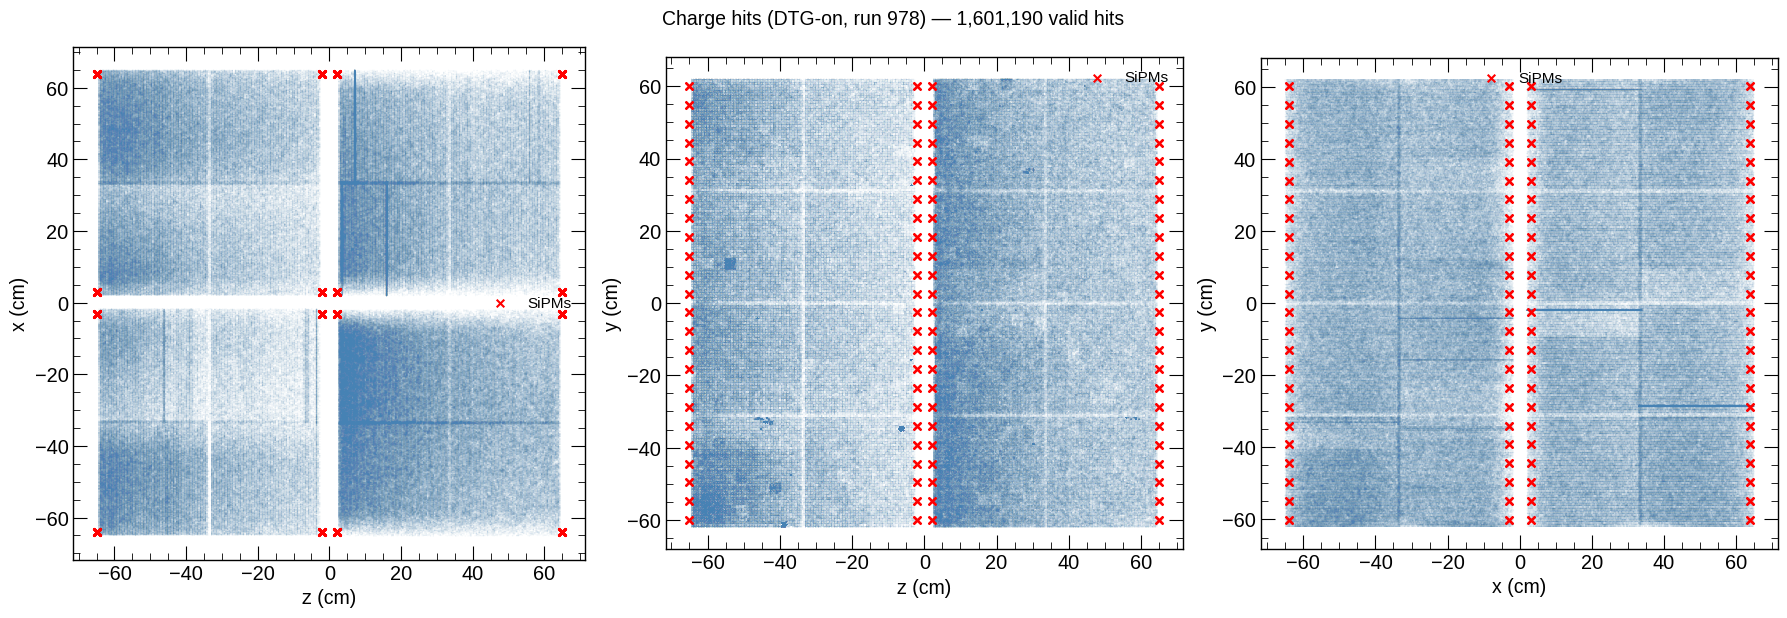

In [14]:
# Scatter plots of charge hits with SiPM overlay
projs = [(2, 0, "z (cm)", "x (cm)"),
         (2, 1, "z (cm)", "y (cm)"),
         (0, 1, "x (cm)", "y (cm)")]

if valid.sum() > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, (ix, iy, xl, yl) in zip(axes, projs):
        ax.scatter(hit_xyz[valid, ix], hit_xyz[valid, iy], s=1, c="steelblue",
                   alpha=0.05, edgecolors="none", rasterized=True)
        ax.scatter(sipm_pos[:, ix], sipm_pos[:, iy], s=30, c="red",
                   marker="x", linewidths=1.5, zorder=5, label="SiPMs")
        ax.set_xlabel(xl, fontsize=14)
        ax.set_ylabel(yl, fontsize=14)
        ax.set_aspect("equal")
        ax.tick_params(direction="in")
        ax.legend(fontsize=11)

    fig.suptitle(f"Charge hits (DTG-on, run 978) \u2014 {valid.sum():,} valid hits", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No valid charge hits to plot.")

## Distance to Nearest Light Detector

For each valid charge hit, compute the 3D distance to the nearest SiPM.
Define \"near-trap\" as within the configured threshold.

In [ ]:
# 3D distance to nearest SiPM
distances_3d = np.full(len(all_hits), np.nan)
# y-z distance only (more robust if x is unreliable)
distances_yz = np.full(len(all_hits), np.nan)

if valid.sum() > 0:
    d3d, _ = sipm_tree.query(hit_xyz[valid])
    distances_3d[valid] = d3d

    d_yz, _ = sipm_tree_yz.query(hit_xyz[valid, 1:3])
    distances_yz[valid] = d_yz

near_3d = distances_3d < NEAR_TRAP_CM
far_3d = valid & ~near_3d & (distances_3d > 15)

print(f"Near-trap (3D < {NEAR_TRAP_CM} cm): {near_3d.sum():,} hits "
      f"({100*near_3d.sum()/max(valid.sum(),1):.1f}% of valid)")
print(f"Far from trap: {far_3d.sum():,} hits")

# Distance histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dist, label in [
    (axes[0], distances_3d, "3D distance to nearest SiPM (cm)"),
    (axes[1], distances_yz, "y-z distance to nearest SiPM (cm)"),
]:
    vals = dist[valid]
    ax.hist(vals, bins=np.arange(0, 50, 0.5), histtype="step", lw=2, color="k")
    ax.axvline(NEAR_TRAP_CM, color="red", ls="--", lw=2,
               label=f"Threshold = {NEAR_TRAP_CM} cm")
    ax.set_xlabel(label, fontsize=13)
    ax.set_ylabel("Charge hits", fontsize=13)
    ax.set_yscale("log")
    ax.legend(fontsize=12)
    ax.tick_params(direction="in")

plt.tight_layout()
plt.show()

TypeError: ufunc 'bitwise_and' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

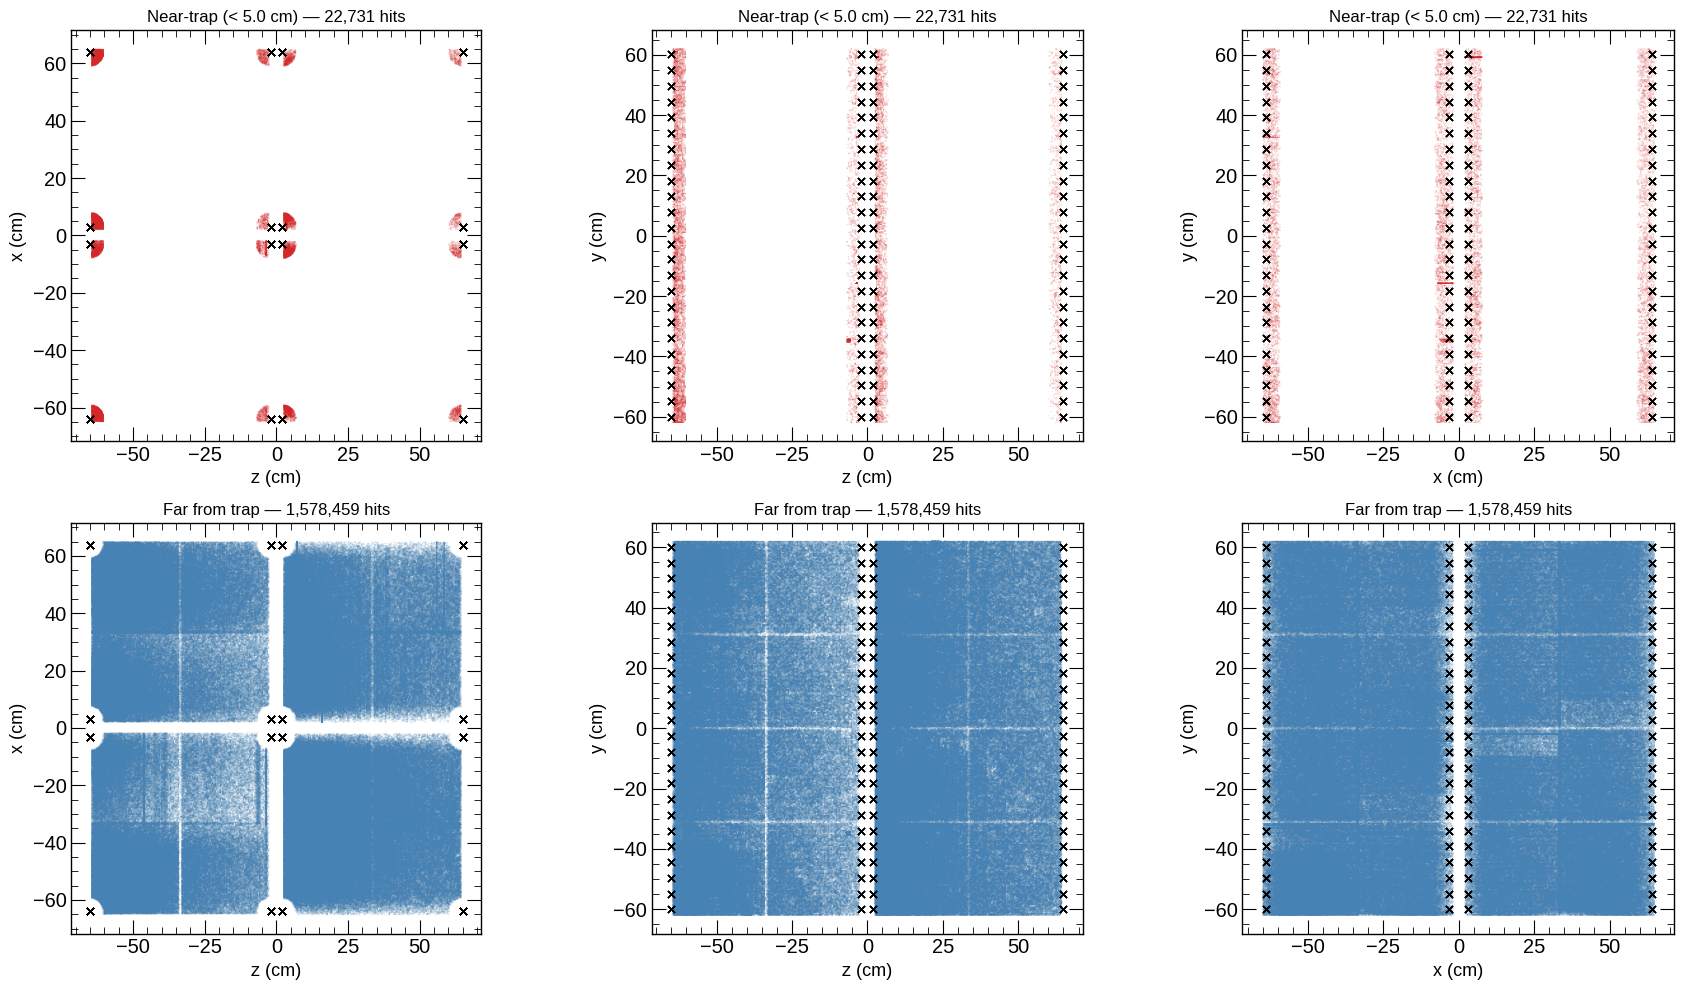

In [32]:
# Spatial distribution: near-trap vs far-from-trap
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (mask, label, color) in enumerate([
    (near_3d, f"Near-trap (< {NEAR_TRAP_CM} cm)", "tab:red"),
    (far_3d, "Far from trap", "steelblue"),
]):
    for j, (ix, iy, xl, yl) in enumerate(projs):
        ax = axes[row, j]
        if mask.sum() > 0:
            ax.scatter(hit_xyz[mask, ix], hit_xyz[mask, iy], s=1, c=color,
                       alpha=0.15, edgecolors="none", rasterized=True)
        ax.scatter(sipm_pos[:, ix], sipm_pos[:, iy], s=25, c="black",
                   marker="x", linewidths=1, zorder=5)
        ax.set_xlabel(xl, fontsize=13)
        ax.set_ylabel(yl, fontsize=13)
        ax.set_aspect("equal")
        ax.tick_params(direction="in")
        ax.set_title(f"{label} \u2014 {mask.sum():,} hits", fontsize=12)

plt.tight_layout()
plt.show()

## Near-Trap vs Far-from-Trap: Light Properties

Classify **events** as \"near-trap\" if any of their charge hits
is within the threshold distance. Compare fprompt-energy distributions.

In [33]:
# Event-level classification across all DTG-on files
fp_near, en_near, npe_near = [], [], []
fp_far, en_far, npe_far = [], [], []
fp_nocharge, en_nocharge, npe_nocharge = [], [], []

for path, r in results_978.items():
    ev_idx = r["event_indices"]
    if len(ev_idx) == 0:
        continue

    hits = r["charge_hits"]
    light_idx = r["charge_light_idx"]

    # Compute per-hit distances for this file
    near_event_set = set()
    charge_event_set = set()

    if len(hits) > 0:
        h_xyz = np.column_stack([hits["x"], hits["y"], hits["z"]])
        h_valid = (np.all(np.isfinite(h_xyz), axis=1) &
                   np.all(np.abs(h_xyz) < COORD_LIMIT, axis=1))
        if h_valid.sum() > 0:
            h_dists = sipm_tree.query(h_xyz[h_valid])[0]
            h_near = h_dists < NEAR_TRAP_CM
            valid_lidx = light_idx[h_valid]
            charge_event_set = set(valid_lidx.tolist())
            near_event_set = set(valid_lidx[h_near].tolist())

    has_near = np.array([int(ei) in near_event_set for ei in ev_idx])
    has_charge = np.array([int(ei) in charge_event_set for ei in ev_idx])
    has_far_only = has_charge & ~has_near
    no_charge = ~has_charge

    fp = r["fprompt_lcm"]
    en = r["energy_lcm"]
    npe = r["n_peaks_lcm"]

    if has_near.sum() > 0:
        fp_near.append(fp[has_near]); en_near.append(en[has_near]); npe_near.append(npe[has_near])
    if has_far_only.sum() > 0:
        fp_far.append(fp[has_far_only]); en_far.append(en[has_far_only]); npe_far.append(npe[has_far_only])
    if no_charge.sum() > 0:
        fp_nocharge.append(fp[no_charge]); en_nocharge.append(en[no_charge]); npe_nocharge.append(npe[no_charge])

def _cat(lst):
    return np.concatenate(lst, axis=0) if lst else np.array([]).reshape(0, 0)

n_ev_near = sum(r.shape[0] for r in fp_near) if fp_near else 0
n_ev_far = sum(r.shape[0] for r in fp_far) if fp_far else 0
n_ev_nc = sum(r.shape[0] for r in fp_nocharge) if fp_nocharge else 0

print(f"Events with near-trap charge: {n_ev_near:,}")
print(f"Events with far-only charge:  {n_ev_far:,}")
print(f"Events with no valid charge:  {n_ev_nc:,}")

Events with near-trap charge: 3,564
Events with far-only charge:  753
Events with no valid charge:  8,227


Clean near trap-entries:  34,634
Clean far trap-entries:   5,502


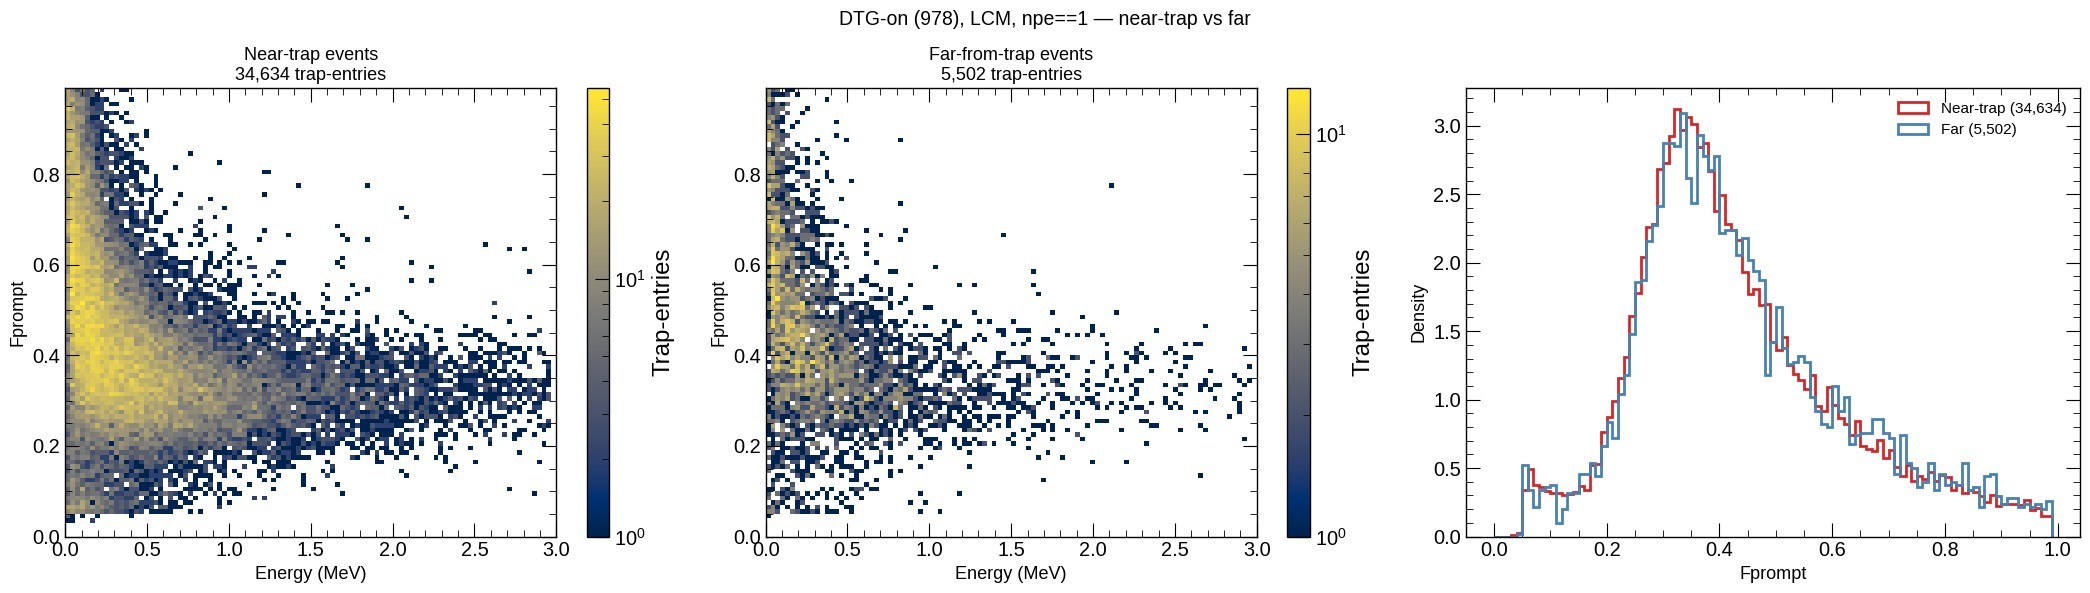

In [34]:
# Fprompt vs energy: near-trap vs far-from-trap
fp_n = _cat(fp_near).ravel();  en_n = _cat(en_near).ravel();  npe_n = _cat(npe_near).ravel()
fp_f = _cat(fp_far).ravel();   en_f = _cat(en_far).ravel();   npe_f = _cat(npe_far).ravel()

en_n_mev = en_n / LCM_ENERGY_NORM * ENERGY_SCALE / N_MODULES
en_f_mev = en_f / LCM_ENERGY_NORM * ENERGY_SCALE / N_MODULES
clean_n = np.isfinite(fp_n) & np.isfinite(en_n_mev) & (npe_n == 1)
clean_f = np.isfinite(fp_f) & np.isfinite(en_f_mev) & (npe_f == 1)

print(f"Clean near trap-entries:  {clean_n.sum():,}")
print(f"Clean far trap-entries:   {clean_f.sum():,}")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

ax = axes[0]
if clean_n.sum() > 0:
    h = ax.hist2d(en_n_mev[clean_n], fp_n[clean_n], bins=[EN_BINS, FP_BINS], norm=LogNorm())
    plt.colorbar(h[3], ax=ax, label="Trap-entries")
ax.set_title(f"Near-trap events\n{clean_n.sum():,} trap-entries", fontsize=13)
ax.set_xlabel("Energy (MeV)", fontsize=13)
ax.set_ylabel("Fprompt", fontsize=13)
ax.set_xlim(0, 3)
ax.tick_params(direction="in")

ax = axes[1]
if clean_f.sum() > 0:
    h = ax.hist2d(en_f_mev[clean_f], fp_f[clean_f], bins=[EN_BINS, FP_BINS], norm=LogNorm())
    plt.colorbar(h[3], ax=ax, label="Trap-entries")
ax.set_title(f"Far-from-trap events\n{clean_f.sum():,} trap-entries", fontsize=13)
ax.set_xlabel("Energy (MeV)", fontsize=13)
ax.set_ylabel("Fprompt", fontsize=13)
ax.set_xlim(0, 3)
ax.tick_params(direction="in")

ax = axes[2]
if clean_n.sum() > 0:
    ax.hist(fp_n[clean_n], bins=FP_BINS, histtype="step", lw=2, color="tab:red",
            label=f"Near-trap ({clean_n.sum():,})", density=True)
if clean_f.sum() > 0:
    ax.hist(fp_f[clean_f], bins=FP_BINS, histtype="step", lw=2, color="steelblue",
            label=f"Far ({clean_f.sum():,})", density=True)
ax.set_xlabel("Fprompt", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.legend(fontsize=11)
ax.tick_params(direction="in")

fig.suptitle(f"DTG-on (978), {DETECTOR.upper()}, npe==1 \u2014 near-trap vs far", fontsize=14)
plt.tight_layout()
plt.show()

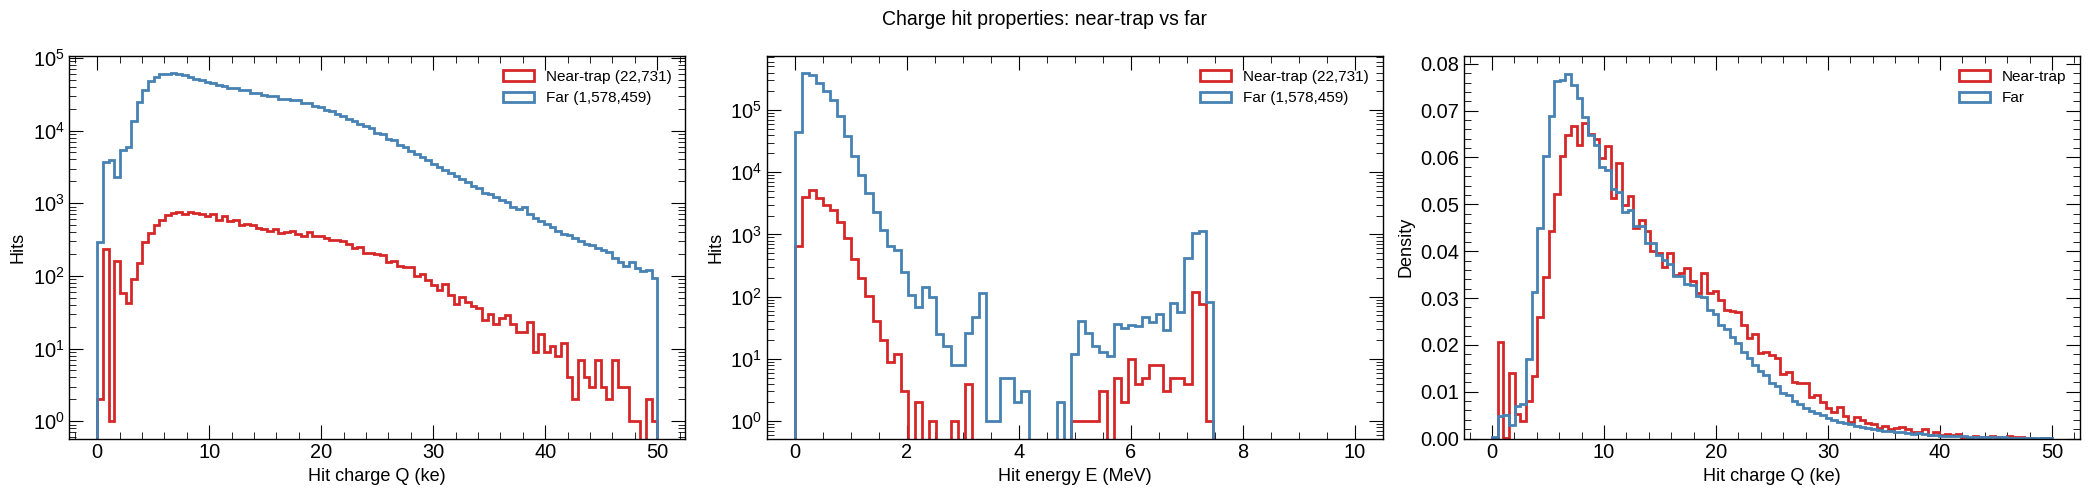

In [35]:
# Hit charge (Q) and energy (E) distributions: near-trap vs far
near_hits = all_hits[near_3d]
far_hits = all_hits[far_3d]

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Q distribution
ax = axes[0]
Q_bins = np.linspace(0, 50, 100)
if len(near_hits) > 0:
    ax.hist(near_hits["Q"], bins=Q_bins, histtype="step", lw=2, color="tab:red",
            label=f"Near-trap ({len(near_hits):,})")
if len(far_hits) > 0:
    ax.hist(far_hits["Q"], bins=Q_bins, histtype="step", lw=2, color="steelblue",
            label=f"Far ({len(far_hits):,})")
ax.set_xlabel("Hit charge Q (ke)", fontsize=13)
ax.set_ylabel("Hits", fontsize=13)
ax.set_yscale("log")
ax.legend(fontsize=11)
ax.tick_params(direction="in")

# E distribution
ax = axes[1]
E_bins = np.linspace(0, 10, 80)
if len(near_hits) > 0:
    ax.hist(near_hits["E"], bins=E_bins, histtype="step", lw=2, color="tab:red",
            label=f"Near-trap ({len(near_hits):,})")
if len(far_hits) > 0:
    ax.hist(far_hits["E"], bins=E_bins, histtype="step", lw=2, color="steelblue",
            label=f"Far ({len(far_hits):,})")
ax.set_xlabel("Hit energy E (MeV)", fontsize=13)
ax.set_ylabel("Hits", fontsize=13)
ax.set_yscale("log")
ax.legend(fontsize=11)
ax.tick_params(direction="in")

# Normalized Q comparison
ax = axes[2]
if len(near_hits) > 0 and len(far_hits) > 0:
    ax.hist(near_hits["Q"], bins=Q_bins, histtype="step", lw=2, color="tab:red",
            label="Near-trap", density=True)
    ax.hist(far_hits["Q"], bins=Q_bins, histtype="step", lw=2, color="steelblue",
            label="Far", density=True)
ax.set_xlabel("Hit charge Q (ke)", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.legend(fontsize=11)
ax.tick_params(direction="in")

fig.suptitle("Charge hit properties: near-trap vs far", fontsize=14)
plt.tight_layout()
plt.show()

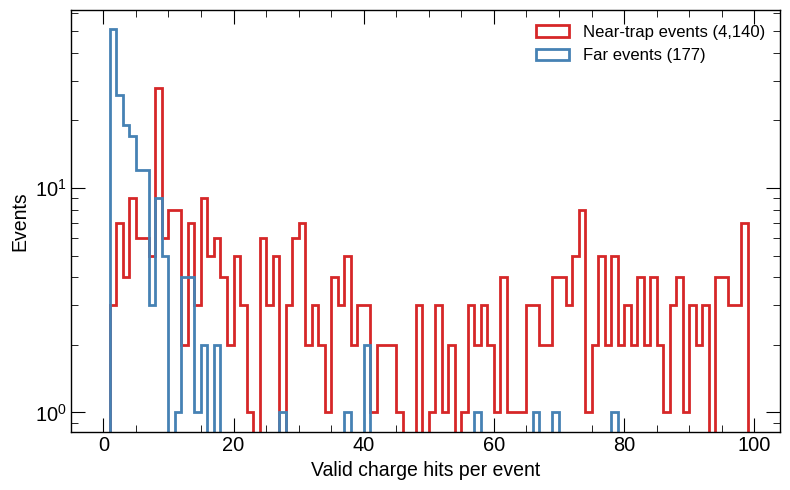

In [20]:
# Hit multiplicity: number of valid charge hits per event, near-trap vs far
# Build per-event hit counts for each category
nhits_near_ev, nhits_far_ev = [], []

for path, r in results_978.items():
    ev_idx = r["event_indices"]
    hits = r["charge_hits"]
    light_idx = r["charge_light_idx"]
    if len(hits) == 0 or len(ev_idx) == 0:
        continue

    h_xyz = np.column_stack([hits["x"], hits["y"], hits["z"]])
    h_valid = (np.all(np.isfinite(h_xyz), axis=1) &
               np.all(np.abs(h_xyz) < COORD_LIMIT, axis=1))

    if h_valid.sum() == 0:
        continue

    h_dists = np.full(len(hits), np.inf)
    h_dists[h_valid] = sipm_tree.query(h_xyz[h_valid])[0]

    for ei in ev_idx:
        mask = (light_idx == ei) & h_valid
        if mask.sum() == 0:
            continue
        evt_dists = h_dists[mask]
        n_near = (evt_dists < NEAR_TRAP_CM).sum()
        n_far = (evt_dists >= NEAR_TRAP_CM).sum()
        if n_near > 0:
            nhits_near_ev.append(mask.sum())  # total valid hits in near-trap events
        else:
            nhits_far_ev.append(mask.sum())

fig, ax = plt.subplots(figsize=(8, 5))
hit_bins = np.arange(0, 100, 1)
if nhits_near_ev:
    ax.hist(nhits_near_ev, bins=hit_bins, histtype="step", lw=2, color="tab:red",
            label=f"Near-trap events ({len(nhits_near_ev):,})")
if nhits_far_ev:
    ax.hist(nhits_far_ev, bins=hit_bins, histtype="step", lw=2, color="steelblue",
            label=f"Far events ({len(nhits_far_ev):,})")
ax.set_xlabel("Valid charge hits per event", fontsize=14)
ax.set_ylabel("Events", fontsize=14)
ax.set_yscale("log")
ax.legend(fontsize=12)
ax.tick_params(direction="in")
plt.tight_layout()
plt.show()

## Decay Data (Runs 979/980)

Process decay reflow files with fixed-peak fprompt and timestamps.
Same light processing as `ar41_decay.ipynb`, plus charge hits.

In [36]:
files_979 = discover_files(REFLOW_DIR, run=979)
files_980 = discover_files(REFLOW_DIR, run=980)
print(f"Run 979 (decay, HV on):  {len(files_979)} files")
print(f"Run 980 (decay, HV off): {len(files_980)} files")

idx_979 = np.linspace(0, len(files_979) - 1, min(N_DECAY_FILES, len(files_979)), dtype=int)
idx_980 = np.linspace(0, len(files_980) - 1, min(N_DECAY_FILES, len(files_980)), dtype=int)
selected_decay = [files_979[i] for i in idx_979] + [files_980[i] for i in idx_980]
print(f"Selected: {len(selected_decay)} files")


def process_decay_file(path, chunk_size=CHUNK_SIZE):
    """Process one decay reflow file: light (fixed fprompt) + charge + timestamps."""
    fp_lcm, en_lcm, np_lcm = [], [], []
    ev_indices, timestamps = [], []

    with h5py.File(path, "r") as h:
        wvfm_ds = h["/light/wvfm/data"]["samples"]
        utime_ms = h["light/events/data"]["utime_ms"]
        n_total = len(wvfm_ds)

        for start in range(0, n_total, chunk_size):
            stop = min(start + chunk_size, n_total)
            raw = wvfm_ds[start:stop, :, :, :500]
            samples = thd_correct(raw.astype(np.float32)); del raw
            saturated = reject_saturation(samples, SAT_THRESHOLD)
            trap_wvfms = sum_to_traps(samples, TRAP_NAME_MAP).astype(np.float32); del samples

            good = ~saturated

            fp, integral = compute_fprompt_fixed(trap_wvfms, PEAK_TICK_FIXED)
            npe = detect_pileup_rising_tail(
                trap_wvfms, PEAK_TICK_FIXED, PILEUP_LOOKBACK, PILEUP_TAIL_REL_HEIGHT
            )
            del trap_wvfms

            fp_lcm.append(fp[good][:, lcm_idx])
            en_lcm.append(integral[good][:, lcm_idx])
            np_lcm.append(npe[good][:, lcm_idx])
            ev_indices.append(np.arange(start, stop)[good])
            timestamps.append(utime_ms[start:stop, 0][good])

    def cat(lst): return np.concatenate(lst, axis=0) if lst else np.array([]).reshape(0, 0)
    good_idx = np.concatenate(ev_indices) if ev_indices else np.array([], dtype=int)

    charge_data = get_charge_hits_for_light_events(path, good_idx)

    return {
        "fprompt_lcm": cat(fp_lcm), "energy_lcm": cat(en_lcm), "n_peaks_lcm": cat(np_lcm),
        "event_indices": good_idx,
        "timestamps": np.concatenate(timestamps) if timestamps else np.array([]),
        "charge_hits": charge_data["hits"],
        "charge_light_idx": charge_data["light_event_idx"],
    }

Run 979 (decay, HV on):  190 files
Run 980 (decay, HV off): 98 files
Selected: 10 files


In [37]:
results_decay = {}

for path in selected_decay:
    fname = os.path.basename(path)
    print(f"Processing {fname} ...", end=" ", flush=True)
    try:
        results_decay[path] = process_decay_file(path)
        r = results_decay[path]
        n_ev = r["fprompt_lcm"].shape[0] if r["fprompt_lcm"].ndim == 2 else 0
        n_hits = len(r["charge_hits"])
        print(f"done  \u2014 {n_ev:,} events, {n_hits:,} charge hits")
    except Exception as e:
        print(f"FAILED: {e}")

total_ev_d = sum(r["fprompt_lcm"].shape[0] for r in results_decay.values()
                 if r["fprompt_lcm"].ndim == 2)
total_hits_d = sum(len(r["charge_hits"]) for r in results_decay.values())
print(f"\nTotal: {total_ev_d:,} events, {total_hits_d:,} charge hits")

Processing mpd_run_run2data_rctl_979_p8_v0p2.FLOW.hdf5 ... 

done  — 4,601 events, 27,710 charge hits
Processing mpd_run_run2data_rctl_979_p270_v0p2.FLOW.hdf5 ... done  — 3,409 events, 47,911 charge hits
Processing mpd_run_run2data_rctl_979_p530_v0p2.FLOW.hdf5 ... done  — 2,809 events, 46,423 charge hits
Processing mpd_run_run2data_rctl_979_p754_v0p2.FLOW.hdf5 ... done  — 3,346 events, 21,081 charge hits
Processing mpd_run_run2data_rctl_979_p941_v0p2.FLOW.hdf5 ... done  — 2,826 events, 1,713 charge hits
Processing mpd_run_run2data_rctl_980_p7_v0p2.FLOW.hdf5 ... done  — 2,868 events, 1,870 charge hits
Processing mpd_run_run2data_rctl_980_p109_v0p2.FLOW.hdf5 ... done  — 5,486 events, 3,287 charge hits
Processing mpd_run_run2data_rctl_980_p221_v0p2.FLOW.hdf5 ... done  — 5,364 events, 3,147 charge hits
Processing mpd_run_run2data_rctl_980_p340_v0p2.FLOW.hdf5 ... done  — 5,142 events, 3,052 charge hits
Processing mpd_run_run2data_rctl_980_p500_v0p2.FLOW.hdf5 ... done  — 4,943 events, 2,858 charge hits

Total: 40,794 events, 159,052 charge hits


Decay events with near-trap charge: 2,182
Decay events with far-only charge:  19,858
Total decay events:                 40,794


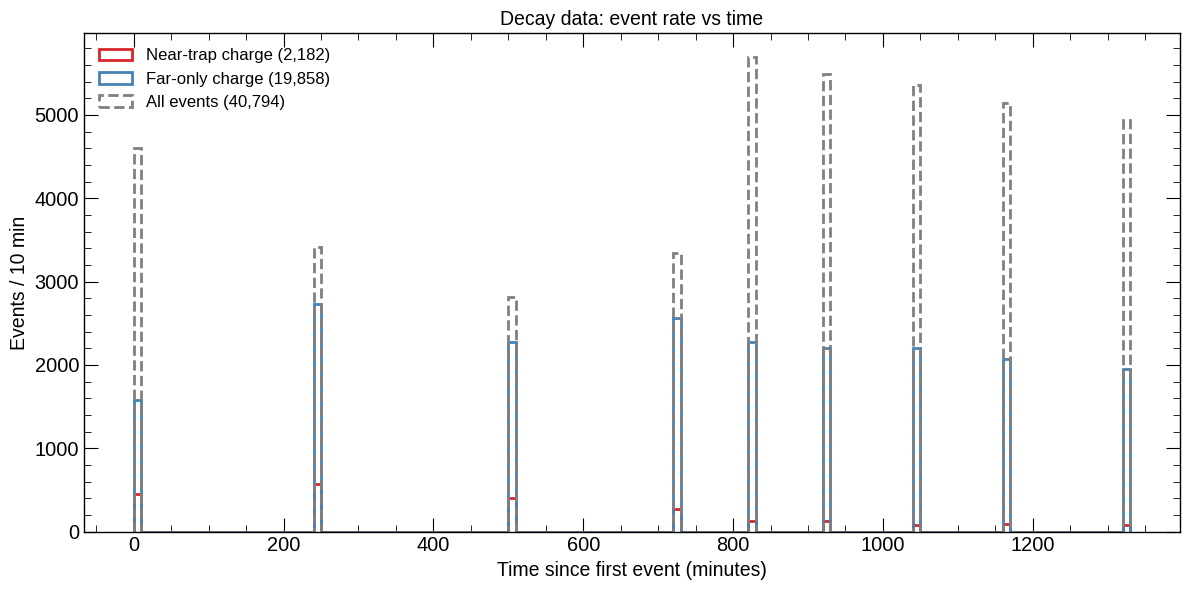

In [38]:
# Near-trap event classification in decay data + time binning
# Collect timestamps for near-trap vs far events
ts_near, ts_far, ts_all = [], [], []

for path, r in results_decay.items():
    ev_idx = r["event_indices"]
    ts = r["timestamps"]
    hits = r["charge_hits"]
    light_idx = r["charge_light_idx"]
    if len(ev_idx) == 0 or len(ts) == 0:
        continue

    near_event_set = set()
    charge_event_set = set()

    if len(hits) > 0:
        h_xyz = np.column_stack([hits["x"], hits["y"], hits["z"]])
        h_valid = (np.all(np.isfinite(h_xyz), axis=1) &
                   np.all(np.abs(h_xyz) < COORD_LIMIT, axis=1))
        if h_valid.sum() > 0:
            h_dists = sipm_tree.query(h_xyz[h_valid])[0]
            h_near = h_dists < NEAR_TRAP_CM
            valid_lidx = light_idx[h_valid]
            charge_event_set = set(valid_lidx.tolist())
            near_event_set = set(valid_lidx[h_near].tolist())

    has_near = np.array([int(ei) in near_event_set for ei in ev_idx])
    has_charge = np.array([int(ei) in charge_event_set for ei in ev_idx])
    has_far_only = has_charge & ~has_near

    ts_near.append(ts[has_near])
    ts_far.append(ts[has_far_only])
    ts_all.append(ts)

ts_near = np.concatenate(ts_near) if ts_near else np.array([])
ts_far = np.concatenate(ts_far) if ts_far else np.array([])
ts_all = np.concatenate(ts_all) if ts_all else np.array([])

print(f"Decay events with near-trap charge: {len(ts_near):,}")
print(f"Decay events with far-only charge:  {len(ts_far):,}")
print(f"Total decay events:                 {len(ts_all):,}")

if len(ts_all) > 0:
    t0 = ts_all.min()
    t_min_near = (ts_near - t0) / 60_000  # ms -> minutes
    t_min_far = (ts_far - t0) / 60_000
    t_min_all = (ts_all - t0) / 60_000
    t_max = t_min_all.max()

    time_bins = np.arange(0, t_max + 10, 10)  # 10-minute bins

    fig, ax = plt.subplots(figsize=(12, 6))
    if len(t_min_near) > 0:
        ax.hist(t_min_near, bins=time_bins, histtype="step", lw=2, color="tab:red",
                label=f"Near-trap charge ({len(ts_near):,})")
    if len(t_min_far) > 0:
        ax.hist(t_min_far, bins=time_bins, histtype="step", lw=2, color="steelblue",
                label=f"Far-only charge ({len(ts_far):,})")
    ax.hist(t_min_all, bins=time_bins, histtype="step", lw=2, color="gray", ls="--",
            label=f"All events ({len(ts_all):,})")
    ax.set_xlabel("Time since first event (minutes)", fontsize=14)
    ax.set_ylabel("Events / 10 min", fontsize=14)
    ax.legend(fontsize=12)
    ax.tick_params(direction="in")
    ax.set_title("Decay data: event rate vs time", fontsize=14)
    plt.tight_layout()
    plt.show()

## Pb-209 Hypothesis Test

**Hypothesis:** Neutrons from the DTG activate lead plated on light traps,
creating Pb-209 which undergoes beta decay.

**Pb-209 properties:**
- Pb-209 \u2192 Bi-209 + e\u207b + \u03bd\u0304\u2091
- Q-value: 644 keV (beta endpoint)
- Half-life: 3.253 hours = 195.2 minutes
- Pure beta emitter (no gamma)

**Predictions if Pb-209 activation is present:**
1. Charge hits concentrated near light traps (\u2714 tested above)
2. **Low fprompt** (electronic recoil from beta, ~0.2\u20130.4)
3. **Energy < 644 keV** (beta endpoint)
4. **Decay time ~3.25 hours** (NOT Ar-41's 109.6 min)

**Key discriminator:** If we see high fprompt near traps \u2192 NOT Pb-209 beta decay.

In [39]:
# Collect fprompt and energy for near-trap decay events
PB209_HALFLIFE_MIN = 3.253 * 60  # 195.2 minutes
PB209_Q_MEV = 0.644  # MeV

fp_near_d, en_near_d, npe_near_d, ts_near_d = [], [], [], []
fp_far_d, en_far_d, npe_far_d = [], [], []

for path, r in results_decay.items():
    ev_idx = r["event_indices"]
    ts = r["timestamps"]
    hits = r["charge_hits"]
    light_idx = r["charge_light_idx"]
    if len(ev_idx) == 0:
        continue

    near_event_set = set()
    charge_event_set = set()
    if len(hits) > 0:
        h_xyz = np.column_stack([hits["x"], hits["y"], hits["z"]])
        h_valid = (np.all(np.isfinite(h_xyz), axis=1) &
                   np.all(np.abs(h_xyz) < COORD_LIMIT, axis=1))
        if h_valid.sum() > 0:
            h_dists = sipm_tree.query(h_xyz[h_valid])[0]
            valid_lidx = light_idx[h_valid]
            charge_event_set = set(valid_lidx.tolist())
            near_event_set = set(valid_lidx[h_dists < NEAR_TRAP_CM].tolist())

    has_near = np.array([int(ei) in near_event_set for ei in ev_idx])
    has_far_only = np.array([int(ei) in charge_event_set for ei in ev_idx]) & ~has_near

    fp = r["fprompt_lcm"]
    en = r["energy_lcm"]
    npe = r["n_peaks_lcm"]

    if has_near.sum() > 0:
        fp_near_d.append(fp[has_near])
        en_near_d.append(en[has_near])
        npe_near_d.append(npe[has_near])
        ts_near_d.append(ts[has_near])
    if has_far_only.sum() > 0:
        fp_far_d.append(fp[has_far_only])
        en_far_d.append(en[has_far_only])
        npe_far_d.append(npe[has_far_only])

fp_nd = _cat(fp_near_d).ravel(); en_nd = _cat(en_near_d).ravel(); npe_nd = _cat(npe_near_d).ravel()
fp_fd = _cat(fp_far_d).ravel();  en_fd = _cat(en_far_d).ravel();  npe_fd = _cat(npe_far_d).ravel()

en_nd_mev = en_nd / LCM_ENERGY_NORM * ENERGY_SCALE / N_MODULES
en_fd_mev = en_fd / LCM_ENERGY_NORM * ENERGY_SCALE / N_MODULES
clean_nd = np.isfinite(fp_nd) & np.isfinite(en_nd_mev) & (npe_nd <= 2)
clean_fd = np.isfinite(fp_fd) & np.isfinite(en_fd_mev) & (npe_fd <= 2)

print(f"Decay near-trap clean trap-entries: {clean_nd.sum():,}")
print(f"Decay far clean trap-entries:       {clean_fd.sum():,}")

Decay near-trap clean trap-entries: 61,096
Decay far clean trap-entries:       556,014


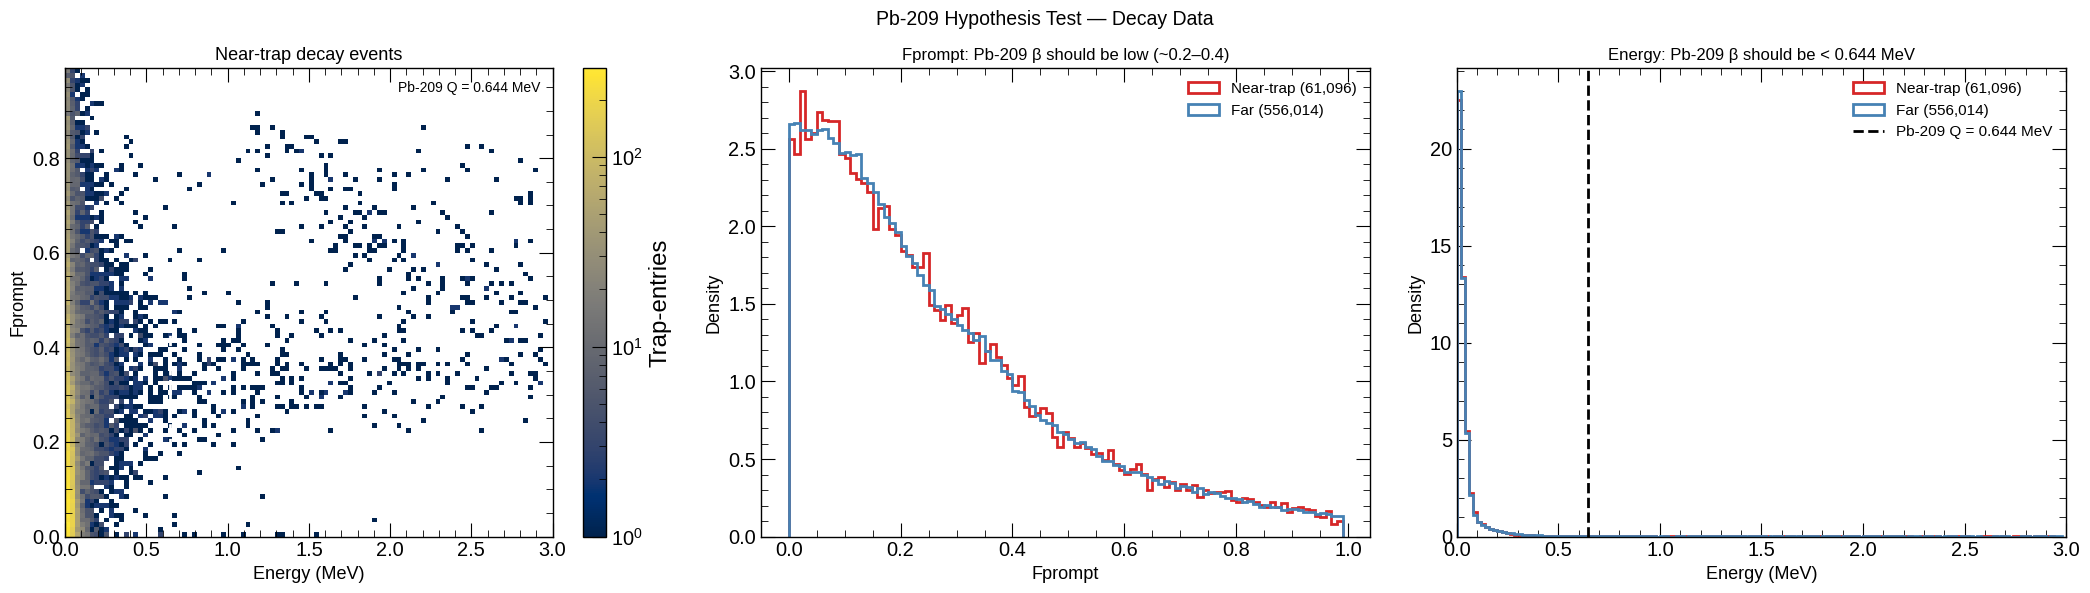

In [40]:
# Pb-209 test 1: Fprompt distribution for near-trap events
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Fprompt-energy 2D for near-trap decay events
ax = axes[0]
if clean_nd.sum() > 0:
    h = ax.hist2d(en_nd_mev[clean_nd], fp_nd[clean_nd], bins=[EN_BINS, FP_BINS], norm=LogNorm())
    plt.colorbar(h[3], ax=ax, label="Trap-entries")
    ax.axvline(PB209_Q_MEV, color="white", ls="--", lw=2, label=f"Pb-209 Q = {PB209_Q_MEV} MeV")
ax.set_xlabel("Energy (MeV)", fontsize=13)
ax.set_ylabel("Fprompt", fontsize=13)
ax.set_xlim(0, 3)
ax.set_title("Near-trap decay events", fontsize=13)
ax.legend(fontsize=10, loc="upper right")
ax.tick_params(direction="in")

# Fprompt 1D: near-trap vs far
ax = axes[1]
if clean_nd.sum() > 0:
    ax.hist(fp_nd[clean_nd], bins=FP_BINS, histtype="step", lw=2, color="tab:red",
            label=f"Near-trap ({clean_nd.sum():,})", density=True)
if clean_fd.sum() > 0:
    ax.hist(fp_fd[clean_fd], bins=FP_BINS, histtype="step", lw=2, color="steelblue",
            label=f"Far ({clean_fd.sum():,})", density=True)
ax.set_xlabel("Fprompt", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title("Fprompt: Pb-209 \u03b2 should be low (~0.2\u20130.4)", fontsize=12)
ax.legend(fontsize=11)
ax.tick_params(direction="in")

# Energy 1D: near-trap vs far, with Pb-209 Q-value marked
ax = axes[2]
en_fine = np.arange(0, 3, 0.02)
if clean_nd.sum() > 0:
    ax.hist(en_nd_mev[clean_nd], bins=en_fine, histtype="step", lw=2, color="tab:red",
            label=f"Near-trap ({clean_nd.sum():,})", density=True)
if clean_fd.sum() > 0:
    ax.hist(en_fd_mev[clean_fd], bins=en_fine, histtype="step", lw=2, color="steelblue",
            label=f"Far ({clean_fd.sum():,})", density=True)
ax.axvline(PB209_Q_MEV, color="k", ls="--", lw=2, label=f"Pb-209 Q = {PB209_Q_MEV} MeV")
ax.set_xlabel("Energy (MeV)", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_xlim(0, 3)
ax.set_title("Energy: Pb-209 \u03b2 should be < 0.644 MeV", fontsize=12)
ax.legend(fontsize=11)
ax.tick_params(direction="in")

fig.suptitle("Pb-209 Hypothesis Test \u2014 Decay Data", fontsize=14)
plt.tight_layout()
plt.show()

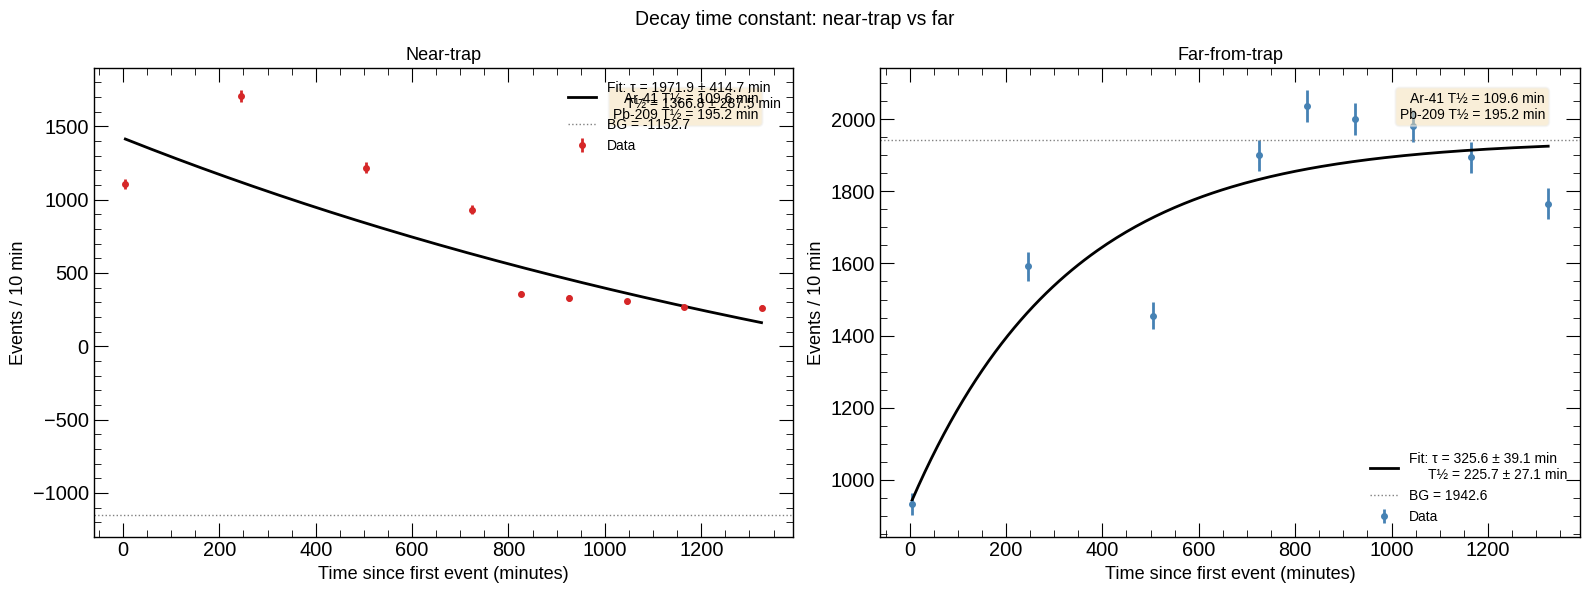

In [26]:
# Pb-209 test 2: Decay time constant for near-trap events
# Fit exponential + constant background to the time distribution

def exp_decay_bg(t, A, tau, C):
    """Exponential decay plus constant background."""
    return A * np.exp(-t / tau) + C


if len(ts_near) > 50 and len(ts_all) > 0:
    t0 = ts_all.min()
    t_near_min = (ts_near - t0) / 60_000
    t_far_min = (ts_far - t0) / 60_000

    time_bins = np.arange(0, t_near_min.max() + 10, 10)
    bin_centers = 0.5 * (time_bins[:-1] + time_bins[1:])

    counts_near, _ = np.histogram(t_near_min, bins=time_bins)
    counts_far, _ = np.histogram(t_far_min, bins=time_bins)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, counts, label, color in [
        (axes[0], counts_near, "Near-trap", "tab:red"),
        (axes[1], counts_far, "Far-from-trap", "steelblue"),
    ]:
        nonzero = counts > 0
        ax.errorbar(bin_centers[nonzero], counts[nonzero],
                    yerr=np.sqrt(counts[nonzero]),
                    fmt="o", ms=4, color=color, label="Data")

        # Fit
        try:
            bc = bin_centers[nonzero]
            cn = counts[nonzero].astype(float)
            p0 = [cn.max(), AR41_HALF_LIFE / np.log(2), cn.min()]
            popt, pcov = curve_fit(exp_decay_bg, bc, cn, p0=p0,
                                  sigma=np.sqrt(cn), absolute_sigma=True,
                                  maxfev=10000)
            perr = np.sqrt(np.diag(pcov))
            t_fit = np.linspace(bc.min(), bc.max(), 200)
            ax.plot(t_fit, exp_decay_bg(t_fit, *popt), "-", color="k", lw=2,
                    label=f"Fit: \u03c4 = {popt[1]:.1f} \u00b1 {perr[1]:.1f} min\n"
                          f"     T\u00bd = {popt[1]*np.log(2):.1f} \u00b1 {perr[1]*np.log(2):.1f} min")
            # Reference lines
            ax.axhline(popt[2], color="gray", ls=":", lw=1, label=f"BG = {popt[2]:.1f}")
        except Exception as e:
            ax.text(0.5, 0.5, f"Fit failed: {e}", transform=ax.transAxes,
                    ha="center", fontsize=11)

        ax.set_xlabel("Time since first event (minutes)", fontsize=13)
        ax.set_ylabel("Events / 10 min", fontsize=13)
        ax.set_title(f"{label}", fontsize=13)
        ax.legend(fontsize=10)
        ax.tick_params(direction="in")

    # Add reference half-lives
    for ax in axes:
        ax.text(0.95, 0.95,
                f"Ar-41 T\u00bd = {AR41_HALF_LIFE:.1f} min\n"
                f"Pb-209 T\u00bd = {PB209_HALFLIFE_MIN:.1f} min",
                transform=ax.transAxes, ha="right", va="top", fontsize=10,
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

    fig.suptitle("Decay time constant: near-trap vs far", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f"Insufficient near-trap events ({len(ts_near)}) for decay fit.")

In [27]:
# Summary of Pb-209 hypothesis test
print("=" * 60)
print("Pb-209 Hypothesis Test Summary")
print("=" * 60)
print()
print("Hypothesis: Pb-208(n,\u03b3)Pb-209 on light trap lead plating")
print(f"  Pb-209 \u2192 Bi-209 + e\u207b + \u03bd\u0304\u2091")
print(f"  Q-value:   {PB209_Q_MEV*1000:.0f} keV")
print(f"  Half-life: {PB209_HALFLIFE_MIN:.1f} min ({PB209_HALFLIFE_MIN/60:.2f} hours)")
print()
print("Test results:")

if clean_nd.sum() > 0:
    fp_med_near = np.nanmedian(fp_nd[clean_nd])
    en_med_near = np.nanmedian(en_nd_mev[clean_nd])
    frac_below_q = (en_nd_mev[clean_nd] < PB209_Q_MEV).mean()
    print(f"  1. Fprompt (near-trap, median):  {fp_med_near:.3f}")
    print(f"     Expected for \u03b2 decay: 0.2\u20130.4")
    print(f"     \u2192 {'CONSISTENT' if 0.15 < fp_med_near < 0.5 else 'INCONSISTENT'} with \u03b2 hypothesis")
    print()
    print(f"  2. Energy (near-trap, median): {en_med_near:.3f} MeV")
    print(f"     Fraction below Q={PB209_Q_MEV} MeV: {100*frac_below_q:.1f}%")
    print(f"     \u2192 {'CONSISTENT' if frac_below_q > 0.3 else 'INCONSISTENT'} with Pb-209 endpoint")
else:
    print("  Insufficient near-trap events for fprompt/energy analysis.")

print()
print("  3. Decay time constant: see fit above")
print(f"     Ar-41 T\u00bd = {AR41_HALF_LIFE:.1f} min")
print(f"     Pb-209 T\u00bd = {PB209_HALFLIFE_MIN:.1f} min")
print()
print("Note: These are preliminary checks. The light energy (from LCMs)")
print("measures scintillation from the LAr, not the \u03b2 energy directly.")
print("A 644 keV \u03b2 produces scintillation proportional to its deposited energy.")

Pb-209 Hypothesis Test Summary

Hypothesis: Pb-208(n,γ)Pb-209 on light trap lead plating
  Pb-209 → Bi-209 + e⁻ + ν̄ₑ
  Q-value:   644 keV
  Half-life: 195.2 min (3.25 hours)

Test results:
  1. Fprompt (near-trap, median):  0.089
     Expected for β decay: 0.2–0.4
     → INCONSISTENT with β hypothesis

  2. Energy (near-trap, median): 0.005 MeV
     Fraction below Q=0.644 MeV: 98.2%
     → CONSISTENT with Pb-209 endpoint

  3. Decay time constant: see fit above
     Ar-41 T½ = 109.6 min
     Pb-209 T½ = 195.2 min

Note: These are preliminary checks. The light energy (from LCMs)
measures scintillation from the LAr, not the β energy directly.
A 644 keV β produces scintillation proportional to its deposited energy.
